In [16]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import norm
from math import sqrt
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

def iad(clinical_tbl):
    '''
    iad = in analysis dataset
    '''
    return clinical_tbl.loc[clinical_tbl['in_analysis_dataset']].copy()

In [17]:
proj_dir_target = os.path.join(nbl_consts['official_indir'], 'TARGET')
proj_dir_henrich = os.path.join(nbl_consts['official_indir'], 'Henrich')

figure_outdir = os.path.join(nbl_consts['repo_dir'], 'figures_revision')
os.makedirs(figure_outdir, exist_ok=True)

covar_path_outdir = os.path.join(figure_outdir, 'covar_path')
os.makedirs(covar_path_outdir, exist_ok=True)

In [18]:
clinical = {}

# Import TARGET clinical table
clinical['TARGET'] = pd.read_table(
    os.path.join(proj_dir_target, 'clinical.processed.withAges.tsv')
)
clinical['TARGET'] = clinical['TARGET'].set_index('submitter_id')
clinical['Henrich'] = pd.read_table(
    os.path.join(proj_dir_henrich, 'clinical.processed.withAges.tsv')
).set_index('Sample_geo_accession')

print(f"TARGET cohort has {clinical['TARGET'].shape[0]} records, {clinical['TARGET']['in_analysis_dataset'].sum()} in the analysis cohort")
print(f"Henrich cohort has {clinical['Henrich'].shape[0]} records, {clinical['Henrich']['in_analysis_dataset'].sum()} in the analysis cohort")

TARGET cohort has 157 records, 157 in the analysis cohort
Henrich cohort has 105 records, 105 in the analysis cohort


In [42]:
# clinical_target_old = pd.read_table(
#     r'C:\Users\DanMonyak\Box\PROJECT 06023□ MolClocks\Neuroblastoma_Paper\Datasets\TARGET\Archive\clinical.processed.withAges.tsv',
#     index_col='submitter_id'
# )
# nbl_util.pearsonCorrelation(
#     clinical['TARGET']['phi'],
#     clinical_target_old['phi']
# )

## Check convergence statistics

In [50]:
gmm_results_target = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'TARGET.GMM_results.csv'), index_col=0)
gmm_results_henrich = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'Henrich.GMM_results.csv'), index_col=0)

gmm_results_target.index = gmm_results_target.index.map(lambda x:x.replace('.', '-'))


TARGET_analysis_sample_IDs = iad(clinical['TARGET'])['sampleID']
Henrich_analysis_sample_IDs = iad(clinical['Henrich']).index

TARGET_Rhat = gmm_results_target.loc[TARGET_analysis_sample_IDs, gmm_results_target.columns.str.endswith('.Rhat')]
print(f'Rhat range in TARGET: ({TARGET_Rhat.min().min():.3f}, {TARGET_Rhat.max().max():.3f})')

TARGET_n_eff = gmm_results_target.loc[TARGET_analysis_sample_IDs, gmm_results_target.columns.str.endswith('n_eff')]
print(f'ESS range in TARGET: ({TARGET_n_eff.min().min():.0f}, {TARGET_n_eff.max().max():.0f})')

Henrich_Rhat = gmm_results_henrich.loc[Henrich_analysis_sample_IDs, gmm_results_henrich.columns.str.endswith('.Rhat')]
print(f'Rhat range in Henrich: ({Henrich_Rhat.min().min():.3f}, {Henrich_Rhat.max().max():.3f})')

Henrich_n_eff = gmm_results_henrich.loc[Henrich_analysis_sample_IDs, gmm_results_henrich.columns.str.endswith('n_eff')]
print(f'ESS range in Henrich: ({Henrich_n_eff.min().min():.0f}, {Henrich_n_eff.max().max():.0f})')


# Check convergence for sensitivity analysis
gmm_results_target_split1 = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'SENSITIVITY_SPLIT1.TARGET.GMM_results.csv'), index_col=0)
gmm_results_target_split1.index = gmm_results_target_split1.index.map(lambda x: nbl_util.getSampleID(x.replace('.', '-')))

gmm_results_target_split2 = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'SENSITIVITY_SPLIT2.TARGET.GMM_results.csv'), index_col=0)
gmm_results_target_split2.index = gmm_results_target_split2.index.map(lambda x: nbl_util.getSampleID(x.replace('.', '-')))

#
print()
split1_TARGET_Rhat = gmm_results_target_split1.loc[TARGET_analysis_sample_IDs, gmm_results_target_split1.columns.str.endswith('.Rhat')]
print(f'Split1 -- Rhat range in TARGET: ({split1_TARGET_Rhat.min().min():.3f}, {split1_TARGET_Rhat.max().max():.3f})')

split1_TARGET_n_eff = gmm_results_target_split1.loc[TARGET_analysis_sample_IDs, gmm_results_target_split1.columns.str.endswith('n_eff')]
print(f'Split1 -- ESS range in TARGET: ({split1_TARGET_n_eff.min().min():.0f}, {split1_TARGET_n_eff.max().max():.0f})')
#
print()
split2_TARGET_Rhat = gmm_results_target_split2.loc[TARGET_analysis_sample_IDs, gmm_results_target_split2.columns.str.endswith('.Rhat')]
print(f'split2 -- Rhat range in TARGET: ({split2_TARGET_Rhat.min().min():.3f}, {split2_TARGET_Rhat.max().max():.3f})')

split2_TARGET_n_eff = gmm_results_target_split2.loc[TARGET_analysis_sample_IDs, gmm_results_target_split2.columns.str.endswith('n_eff')]
print(f'split2 -- ESS range in TARGET: ({split2_TARGET_n_eff.min().min():.0f}, {split2_TARGET_n_eff.max().max():.0f})')

Rhat range in TARGET: (1.000, 1.014)
ESS range in TARGET: (199, 13841)
Rhat range in Henrich: (1.000, 1.002)
ESS range in Henrich: (2552, 15253)

Split1 -- Rhat range in TARGET: (1.000, 1.018)
Split1 -- ESS range in TARGET: (190, 15331)

split2 -- Rhat range in TARGET: (1.000, 1.004)
split2 -- ESS range in TARGET: (1212, 14838)


In [47]:
gmm_results_target_split1

,psi[1].mean,psi[2].mean,psi[3].mean,X.mean,N.mean,mu_left.mean,mu_right.mean,mu_middle.mean,var_left.mean,var_right.mean,...,mu_right.Rhat,mu_middle.Rhat,var_left.Rhat,var_right.Rhat,var_middle.Rhat,sigma_left.Rhat,sigma_right.Rhat,sigma_middle.Rhat,phi.Rhat,lp__.Rhat
TARGET-30-PAIFXV-01A,0.075233,0.607663,0.317104,0.313611,21.625152,0.313611,0.686389,0.5,0.010304,0.010304,...,1.000661,NaN,1.000839,1.000839,1.000858,1.000826,1.000826,1.000845,1.000714,1.000999
TARGET-30-PAIPGU-01A,0.577029,0.366297,0.056674,0.259673,19.534028,0.259673,0.740327,0.5,0.009908,0.009908,...,1.000763,NaN,1.000097,1.000097,0.999991,1.000090,1.000090,0.999990,1.000774,1.000129
TARGET-30-PAISNS-01A,0.231506,0.443758,0.324736,0.252564,23.942393,0.252564,0.747436,0.5,0.007939,0.007939,...,1.000183,NaN,0.999998,0.999998,1.000030,0.999989,0.999989,1.000021,1.000174,1.000998
TARGET-30-PAITCI-01A,0.166099,0.516512,0.317388,0.300210,17.621861,0.300210,0.699790,0.5,0.012124,0.012124,...,1.000501,NaN,1.000266,1.000266,1.000259,1.000284,1.000284,1.000274,1.000578,1.001255
TARGET-30-PAIVHE-01A,0.263189,0.453098,0.283713,0.357847,23.129525,0.357847,0.642153,0.5,0.010250,0.010250,...,1.000885,NaN,1.001292,1.001292,1.001301,1.001111,1.001111,1.001149,1.002070,1.001647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TARGET-30-PATHKB-01A,0.086855,0.457651,0.455494,0.246375,20.765619,0.246375,0.753625,0.5,0.009010,0.009010,...,1.000195,NaN,0.999923,0.999923,0.999958,0.999919,0.999919,0.999952,1.000196,1.000224
TARGET-30-PATHVK-01A,0.295835,0.373484,0.330681,0.286581,24.693817,0.286581,0.713419,0.5,0.008361,0.008361,...,1.000154,NaN,1.000100,1.000100,1.000079,1.000090,1.000090,1.000069,1.000155,1.000347
TARGET-30-PATNKP-01A,0.180763,0.366040,0.453197,0.234900,21.154166,0.234900,0.765100,0.5,0.008542,0.008542,...,1.000551,NaN,0.999825,0.999825,0.999855,0.999830,0.999830,0.999855,1.000547,1.000926
TARGET-30-PATYIL-01A,0.142107,0.429808,0.428085,0.278684,22.315053,0.278684,0.721316,0.5,0.009099,0.009099,...,1.000366,NaN,1.000346,1.000346,1.000349,1.000348,1.000348,1.000355,1.000359,1.000199


## Make Figures

In [5]:
## Configure graph
sf = nbl_consts['sf']
figsize = np.array([7, 4])
sns.set(rc={"savefig.bbox":'tight', 'axes.linewidth':sf}, font_scale=1, style='ticks')

In [6]:
# ## Must set dataframe names for use of saveBoxPlotNew and saveCorrelationPlot

clinical['TARGET'].name = 'Discovery'
clinical['Henrich'].name = 'Validation'

### 3 example tumors

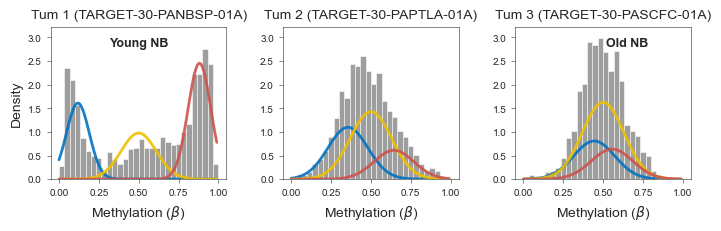

In [7]:
## Plot beta value distriubtions for 3 example tumors

beta_values_Clock = pd.read_table(
    os.path.join(nbl_consts['official_indir'], 'TARGET', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'),
    index_col=0)

sample_list = {
    # 'Tum1':'TARGET-30-PANUKV-01A',
    'Tum 1':'TARGET-30-PANBSP-01A',
    'Tum 2':'TARGET-30-PAPTLA-01A',
    'Tum 3':'TARGET-30-PASCFC-01A'
}

# Create plot axes
fig, axes = plt.subplots(1, len(sample_list), figsize=np.array(figsize) * [2.5, 1.2] * sf)
fig.tight_layout(pad=0.2)

# Color of each distribution in order (left -> right)
chosen_tumor_colors = [nbl_consts['palette_jco'][i] for i in [0, 1, 3]]

# X coordinates for curves
x_vals = np.linspace(0, 0.99, 100)

for i, tum_id in enumerate(sample_list):
    ax = axes[i]
    samp = sample_list[tum_id]
    patient = nbl_util.sampleToPatientID(samp)
    
    # Plot distribution
    sns.histplot(ax=ax, x=beta_values_Clock[samp], stat='density',
                 color=nbl_consts['palette_jco'][2],
                 bins=30, alpha=nbl_consts['opacity'],
                binrange=(0, 1))
    
    # Customize plot
    ax.set_title(f'{tum_id} ({samp})', fontsize=nbl_consts['labelfontsize'] * sf)
    ax.set_xlabel(r'Methylation ($\beta$)', fontsize=nbl_consts['labelfontsize'] * sf)
    if i == 0: # Only have y-axis label on left-most plot
        ax.set_ylabel('Density', fontsize=nbl_consts['labelfontsize'] * sf)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

    # Weight of each of three distributions
    weight_list = gmm_results_target.loc[samp, ['psi[1].mean', 'psi[2].mean', 'psi[3].mean']].values
    
    # Holds the max y-axis limit max
    y_max = float('-Inf')
    
    X_mean = gmm_results_target.loc[samp, 'X.mean']
    N_mean = gmm_results_target.loc[samp, 'N.mean']
    mu_list = [X_mean, 0.5, 1 - X_mean]
    sd_list = [sqrt(mu * (1 - mu) / N_mean) for mu in mu_list]
    
    # Plot each distribution
    for j in range(weight_list.shape[0]):

        # X and Y coords for curve
        y_vals = norm.pdf(x_vals, mu_list[j], sd_list[j]) * weight_list[j]
        
        # Plot curve
        ax.plot(x_vals, y_vals, lw=2, alpha=0.9,
                color=chosen_tumor_colors[j]
               )
        
        # Update max
        y_max = max(y_max, ax.get_ylim()[1])
    
#     y_vals_kernel = np.stack([norm.pdf(x_vals, mu_list[j], sd_list[j]) * weight_list[j] for j in range(weight_list.shape[0])], axis=0).sum(axis=0)
#     ax.plot(x_vals, y_vals_kernel, lw=1, alpha=0.9, color='gray')
    
# Align y-axis limits
for i in range(len(sample_list)):
    ax = axes[i]
    ax.set_ylim(0, y_max * 1.03)

for i, text, x_pos in zip([0, 2], ['Young NB', 'Old NB'], [0.5, 0.65]):
    axes[i].text(x_pos, y_max * 0.9,
            text,
                 # color='Black',
            ha="center", fontfamily='sans-serif', fontsize=0.9 * nbl_consts['labelfontsize'] * sf, fontweight='bold',
                 # alpha=nbl_consts['opacity']
           )

# Save figure
file_format = 'svg'
fig.savefig(os.path.join(figure_outdir, f'example_peak_decomp.{file_format}'), format=file_format, pad_inches=0.1)

# Tumor mitotic age distribution

## Histogram

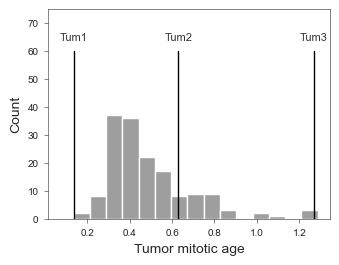

In [8]:
plot_data = clinical['TARGET'].loc[clinical['TARGET']['in_analysis_dataset'], 'phi']

# Create plot
fig, ax = plt.subplots(figsize=figsize * [1.3, 1.7] * sf)
sns.histplot(ax=ax, x=plot_data,
             color=nbl_consts['palette_jco'][2], alpha=nbl_consts['opacity'])

# Mark (with vertical lines) the c_beta values of three
#   example tumors from plot in the previous cell
line_color = 'black'
tumor_heights = [0.8, 0.8, 0.8]

x_0 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 1']), 'phi']
x_1 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 2']), 'phi']
x_2 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 3']), 'phi']

ax.axvline(x=x_0, ymax=tumor_heights[0], lw=2.5 * sf, color=line_color)
ax.axvline(x=x_1, ymax=tumor_heights[1], lw=2.5 * sf, color=line_color)
ax.axvline(x=x_2, ymax=tumor_heights[2], lw=2.5 * sf, color=line_color)

# Customize figure
ax.set_xlabel('Tumor mitotic age', fontsize=nbl_consts['labelfontsize']*sf)
ax.set_ylabel('Count', fontsize=nbl_consts['labelfontsize'] * sf)
ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)
ax.set_ylim(top=75)

# Widen plot a little
xlim = ax.get_xlim()
width = xlim[1] - xlim[0]
ax.set_xlim(left = xlim[0] - width/20)

# Annotate the vertical lines with text for all 3 tumors
y_height = ax.get_ylim()[1]

ax.text(x_0, (tumor_heights[0]+0.05)*y_height,
        'Tum1', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )
ax.text(x_1, (tumor_heights[1]+0.05)*y_height,
        'Tum2', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )
ax.text(x_2-0.005, (tumor_heights[2]+0.05)*y_height,
        'Tum3', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )

# Save figure
file_format = 'svg'
fig.savefig(os.path.join(figure_outdir, f'mitotic_age_distribution.{file_format}'), format=file_format, pad_inches=0.1)

## Beeswarm

In [9]:
sample_list_inverse = dict(map(lambda x:x[::-1], list(sample_list.items())))
clinical['TARGET']['TumLabeled'] = clinical['TARGET']['sampleID'].map(sample_list_inverse).fillna('Others')

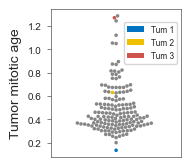

In [10]:
# Create plot
fig, ax = plt.subplots(figsize=figsize * [1 * 0.6, 1.2] * sf)
point_size = 16

#########################################
########### Mitotic age (phi) ###########
#########################################

jco = nbl_consts['palette_jco']
color_dict = dict(zip(['Others', 'Tum 1', 'Tum 2', 'Tum 3'], [jco[2], jco[0], jco[1], jco[3]]))

sns.swarmplot(
    ax=ax,
    data=iad(clinical['TARGET']),
    y='phi',
    palette=color_dict,
    hue='TumLabeled',
    legend=False,
    s=point_size * sf**2
)

# Customize figure
ax.set_xlabel('')
ax.set_ylabel('Tumor mitotic age', fontsize=nbl_consts['labelfontsize'] * sf)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

# Legend
patches = [
    mpatches.Patch(color=color_dict[group], label=group, alpha=1, lw=0)
    for group in [f'Tum {i}' for i in range(1, 4)]
]

plots_x, plots_y = ax.get_position().get_points()[1]
fig.legend(handles=patches,
           loc='upper right',
           bbox_to_anchor=(plots_x, plots_y * 0.95),
           fontsize= 0.6 * nbl_consts['labelfontsize'] * sf
          )

# Save figure
fig.savefig(os.path.join(figure_outdir, 'mitotic_age_divisions_beeswarm.svg'), format='svg', pad_inches=0.1)

# Covariate Analysis

In [51]:
def make_target_plots(var_y, outdir, filename):

    fig, axes = plt.subplots(2, 2, figsize=figsize * [2.5, 2.5] * sf)
    fig.tight_layout(pad = 4 * sf)

    nbl_util.saveBoxPlotNew(clinical['TARGET'], 'Stage grouped', restrict=True,
                            ax=axes[0, 0],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.1,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            # outdir=outdir,
                            use_groups=['Stage 1/2/3/4S', 'Stage 4'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['TARGET'], 'Risk grouped', restrict=True,
                            ax=axes[0, 1],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.1,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            # outdir=outdir,
                            use_groups=['Low/intermediate risk', 'High risk'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['TARGET'], 'MYCN status', restrict=True,
                            ax=axes[1, 0],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.1,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            # outdir=outdir,
                            use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['TARGET'], 'Age >= 1.5', restrict=True,
                            ax=axes[1, 1],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.1,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age',
                            # outdir=outdir,
                            file_format='svg',
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['TARGET'], 'sex_at_birth', restrict=True,
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.02,
                            palette=nbl_consts['palette_jco'], xlabel='Sex at birth', ylabel='Tumor mitotic age', file_format='svg',
                            outdir=outdir,
                            figsize=np.array([7, 5]), labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    fig.savefig(os.path.join(outdir, filename), format='svg', pad_inches=0.4)


def make_henrich_plots(var_y, outdir, filename):

    fig, axes = plt.subplots(2, 2, figsize=figsize * [2.5, 2.5] * sf)
    fig.tight_layout(pad = 4 * sf)

    nbl_util.saveBoxPlotNew(clinical['Henrich'], 'Stage grouped', restrict=True,
                            ax=axes[0, 0],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.03,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            outdir=covar_path_outdir,
                            use_groups=['Stage 1/2/3/4S', 'Stage 4'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['Henrich'], 'Risk grouped', restrict=True,
                            ax=axes[0, 1],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.03,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            outdir=covar_path_outdir,
                            use_groups=['Low/intermediate risk', 'High risk'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['Henrich'], 'mycn status', restrict=True,
                            ax=axes[1, 0],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.023,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                            outdir=covar_path_outdir, use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    nbl_util.saveBoxPlotNew(clinical['Henrich'], 'age at diagnosis', restrict=True,
                            ax=axes[1, 1],
                            var_y=var_y, outfile=False, title=False, signif_bar_heights = 0.02,
                            palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age',
                            outdir=covar_path_outdir, file_format='svg',
                            figsize=figsize * [1, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

    fig.savefig(os.path.join(outdir, filename), format='svg', pad_inches=0.4)


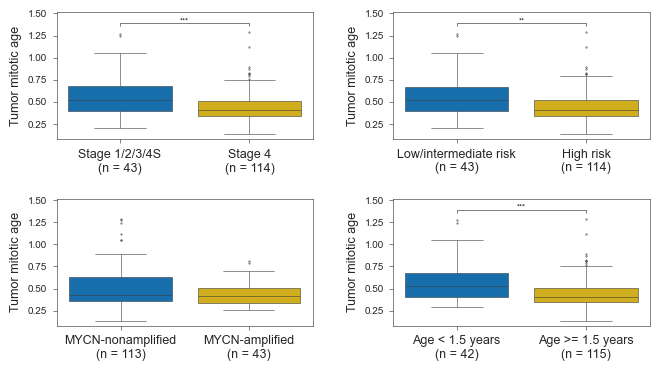

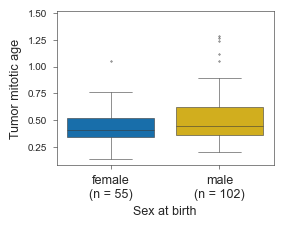

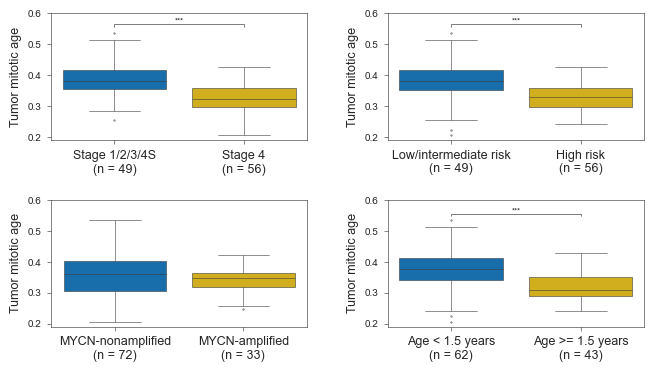

In [52]:
make_target_plots('phi', covar_path_outdir, 'TARGET_combined_covar_plots.svg')
make_henrich_plots('phi', covar_path_outdir, 'Henrich_combined_covar_plots.svg')

## Sensitivity analysis

In [13]:
split1_figure_outdir = os.path.join(covar_path_outdir, 'split1')
split2_figure_outdir = os.path.join(covar_path_outdir, 'split2')

os.makedirs(split1_figure_outdir, exist_ok=True)
os.makedirs(split2_figure_outdir, exist_ok=True)

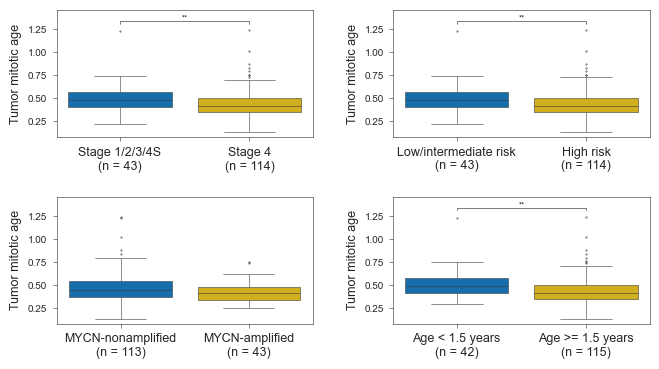

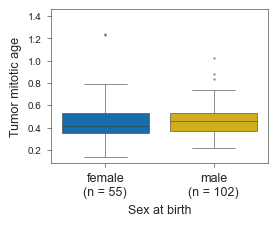

In [14]:
make_target_plots('phi.split1', split1_figure_outdir, 'combined_sensitivity_covar_boxplots.svg')

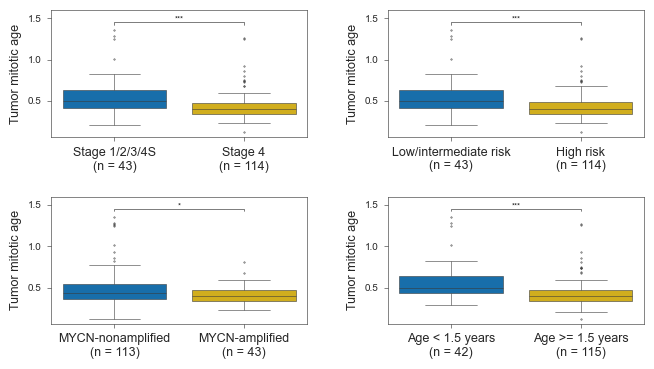

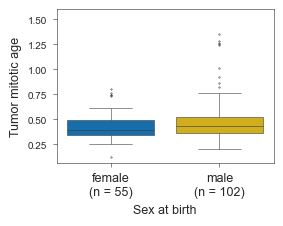

In [15]:
make_target_plots('phi.split2', split2_figure_outdir, 'combined_sensitivity_covar_boxplots.svg')